# Анализ связи лингвистических метрик (ruTS) с вовлеченностью аудитории

В этом ноутбуке объединяются данные:
- Лингвистические метрики из `02_text_with_metrics.csv` (FRE, FKG, TTR, и др.)
- Метрики вовлеченности из `03_engagement.csv` (views_norm, reaction_norm, forward_norm, engagement_rate)

Цели:
1. Корреляционный анализ лингвистических метрик с вовлеченностью
2. Сравнение каналов по лингвистическим метрикам
3. Регрессионный анализ влияния лингвистики на вовлеченность
4. Анализ оптимального диапазона FRE
5. Сравнение оригинальных и capped метрик

Импорты

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

Настройка визуализации

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Загрузка

In [4]:
df_text = pd.read_csv("../data/split/02_text_with_metrics.csv")
df_text.head()

,channel_username,post_id,text,text_clean,text_ruts,text_length,text_length_clean,links_count_entities,has_links_entities,links_from_entities,n_words,n_sents,n_chars,flesch_reading_ease,flesch_kincaid_grade,ttr,words_per_sent,flesch_reading_ease_capped,flesch_kincaid_grade_capped
0,AI_point_of_view,1813,🤔 Искусственный интеллект: угроза или новые во...,искусственный интеллект: угроза или новые возм...,Искусственный интеллект: угроза или новые возм...,1173,148,0,False,[],146.0,8.0,1163.0,8.573014,13.552500,0.821918,18.250000,8.573014,13.552500
1,AI_point_of_view,1809,👩‍🎓 **Самообучение без разметки: лекция Алексе...,самообучение без разметки: лекция алексея зайц...,Самообучение без разметки: лекция Алексея Зайц...,1661,213,0,False,[],215.0,6.0,1597.0,9.582364,19.269264,0.772093,35.833333,9.582364,18.100000
2,AI_point_of_view,1808,📡▶️ **Искусственный интеллект: как научить маш...,искусственный интеллект: как научить машину чу...,Искусственный интеллект: как научить машину «ч...,1519,154,2,True,['https://roscongress.org/sessions/kmu-2025-de...,153.0,11.0,1138.0,34.378672,8.976435,0.830065,13.909091,34.378672,8.976435
3,AI_point_of_view,1805,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,"физика ии от сколтеха владимир вановский, руко...","Физика + ИИ от Сколтеха Владимир Вановский, ру...",1260,151,1,True,['https://t.me/ncfmai'],151.0,4.0,1188.0,-14.181722,22.792268,0.761589,37.750000,-14.181722,18.100000
4,AI_point_of_view,1804,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,завтра: sber conf: open source ai agents! сбер...,ЗАВТРА: Sber Conf: Open Source & AI Agents! Сб...,643,75,1,True,['https://developers.sber.ru/kak-v-sbere/event...,78.0,9.0,541.0,76.909359,2.069487,0.833333,8.666667,76.909359,2.069487


In [5]:
df_eng = pd.read_csv("../data/split/03_engagement.csv")
df_eng.head()

,channel_username,post_id,views,forwards,total_reactions,views_norm,reaction_norm,forward_norm,engagement_rate,log_views_norm,log_reaction_norm,log_forward_norm,log_engagement_rate
0,AI_point_of_view,1813,288,1,10,0.110897,0.034602,0.003460,0.038194,0.105168,0.034017,0.003454,0.037483
1,AI_point_of_view,1809,348,1,20,0.134001,0.057307,0.002865,0.060345,0.125752,0.055725,0.002861,0.058594
2,AI_point_of_view,1808,363,5,12,0.139777,0.032967,0.013736,0.046832,0.130832,0.032435,0.013643,0.045768
3,AI_point_of_view,1805,374,2,12,0.144012,0.032000,0.005333,0.037433,0.134542,0.031499,0.005319,0.036750
4,AI_point_of_view,1804,389,4,8,0.149788,0.020513,0.010256,0.030848,0.139578,0.020305,0.010204,0.030382


In [30]:
df_meta = pd.read_csv("../data/split/01_meta.csv")
channel_mapping = df_meta[['channel_username', 'channel_title']].drop_duplicates(subset=['channel_username'])

Объединение датафреймов

In [31]:
df = df_text.merge(df_eng, on=['channel_username', 'post_id'], how='inner')
df = df.merge(channel_mapping, on='channel_username', how='left')
df.head()

,channel_username,post_id,text,text_clean,text_ruts,text_length,text_length_clean,links_count_entities,has_links_entities,links_from_entities,n_words,n_sents,n_chars,flesch_reading_ease,flesch_kincaid_grade,ttr,words_per_sent,flesch_reading_ease_capped,flesch_kincaid_grade_capped,views,forwards,total_reactions,views_norm,reaction_norm,forward_norm,engagement_rate,log_views_norm,log_reaction_norm,log_forward_norm,log_engagement_rate,channel_title
0,AI_point_of_view,1813,🤔 Искусственный интеллект: угроза или новые во...,искусственный интеллект: угроза или новые возм...,Искусственный интеллект: угроза или новые возм...,1173,148,0,False,[],146.0,8.0,1163.0,8.573014,13.552500,0.821918,18.250000,8.573014,13.552500,288,1,10,0.110897,0.034602,0.003460,0.038194,0.105168,0.034017,0.003454,0.037483,Точка машинного зрения
1,AI_point_of_view,1809,👩‍🎓 **Самообучение без разметки: лекция Алексе...,самообучение без разметки: лекция алексея зайц...,Самообучение без разметки: лекция Алексея Зайц...,1661,213,0,False,[],215.0,6.0,1597.0,9.582364,19.269264,0.772093,35.833333,9.582364,18.100000,348,1,20,0.134001,0.057307,0.002865,0.060345,0.125752,0.055725,0.002861,0.058594,Точка машинного зрения
2,AI_point_of_view,1808,📡▶️ **Искусственный интеллект: как научить маш...,искусственный интеллект: как научить машину чу...,Искусственный интеллект: как научить машину «ч...,1519,154,2,True,['https://roscongress.org/sessions/kmu-2025-de...,153.0,11.0,1138.0,34.378672,8.976435,0.830065,13.909091,34.378672,8.976435,363,5,12,0.139777,0.032967,0.013736,0.046832,0.130832,0.032435,0.013643,0.045768,Точка машинного зрения
3,AI_point_of_view,1805,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,"физика ии от сколтеха владимир вановский, руко...","Физика + ИИ от Сколтеха Владимир Вановский, ру...",1260,151,1,True,['https://t.me/ncfmai'],151.0,4.0,1188.0,-14.181722,22.792268,0.761589,37.750000,-14.181722,18.100000,374,2,12,0.144012,0.032000,0.005333,0.037433,0.134542,0.031499,0.005319,0.036750,Точка машинного зрения
4,AI_point_of_view,1804,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,завтра: sber conf: open source ai agents! сбер...,ЗАВТРА: Sber Conf: Open Source & AI Agents! Сб...,643,75,1,True,['https://developers.sber.ru/kak-v-sbere/event...,78.0,9.0,541.0,76.909359,2.069487,0.833333,8.666667,76.909359,2.069487,389,4,8,0.149788,0.020513,0.010256,0.030848,0.139578,0.020305,0.010204,0.030382,Точка машинного зрения


Проверка на пропуски

In [32]:
key_cols = ['flesch_reading_ease_capped', 'flesch_kincaid_grade_capped', 
            'ttr', 'words_per_sent', 'n_words', 'n_sents',
            'views_norm', 'reaction_norm', 'forward_norm', 'engagement_rate']
print(f"\nПропуски в ключевых колонках:")
for col in key_cols:
    if col in df.columns:
        missing = df[col].isna().sum()
        print(f"  {col}: {missing} ({missing/len(df)*100:.2f}%)")

df.shape


Пропуски в ключевых колонках:
  flesch_reading_ease_capped: 10 (0.10%)
  flesch_kincaid_grade_capped: 10 (0.10%)
  ttr: 10 (0.10%)
  words_per_sent: 10 (0.10%)
  n_words: 10 (0.10%)
  n_sents: 10 (0.10%)
  views_norm: 0 (0.00%)
  reaction_norm: 0 (0.00%)
  forward_norm: 0 (0.00%)
  engagement_rate: 0 (0.00%)


(10420, 31)

Удаляем строки с пропусками в целевых метриках

In [33]:
df_clean = df.dropna(subset=['flesch_reading_ease_capped'])
df_clean.shape

(10410, 31)

## Корреляционный анализ лингвистических метрик с вовлеченностью

In [37]:
# колонки для корреляции
ling_features = [
    'flesch_reading_ease_capped',
    'flesch_kincaid_grade_capped', 
    'ttr'
]

engagement_metrics = [
    'views_norm',
    'reaction_norm', 
    'forward_norm',
    'engagement_rate'
]

Строим корреляционную матрицу

In [38]:
corr_matrix = df_clean[ling_features + engagement_metrics].corr(method='spearman')

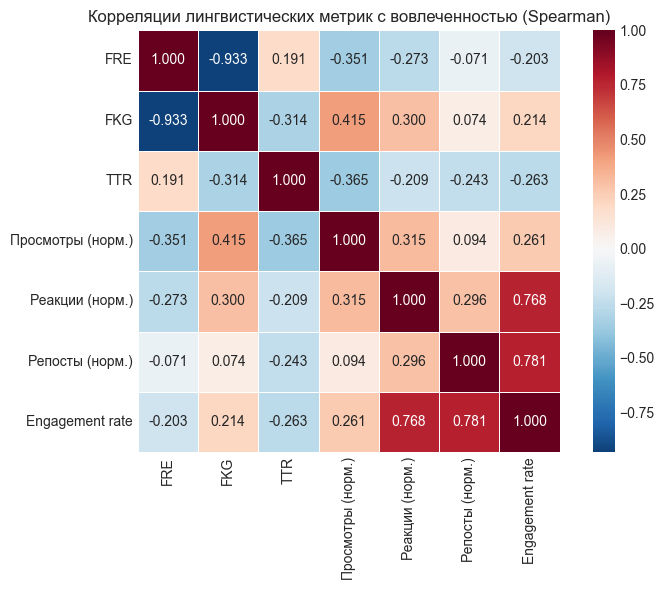

In [41]:
# Словарь для переименования
rename_dict = {
    'flesch_reading_ease_capped': 'FRE',
    'flesch_kincaid_grade_capped': 'FKG',
    'ttr': 'TTR',
    'views_norm': 'Просмотры (норм.)',
    'reaction_norm': 'Реакции (норм.)',
    'forward_norm': 'Репосты (норм.)',
    'engagement_rate': 'Engagement rate'
}

# Для корреляционной матрицы
corr_matrix_renamed = corr_matrix.copy()
corr_matrix_renamed.index = [rename_dict.get(i, i) for i in corr_matrix_renamed.index]
corr_matrix_renamed.columns = [rename_dict.get(i, i) for i in corr_matrix_renamed.columns]

# Тепловая карта
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_renamed, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Корреляции лингвистических метрик с вовлеченностью (Spearman)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/plots/ruts_engagement_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
corr_matrix.loc[ling_features, engagement_metrics].round(3)

,views_norm,reaction_norm,forward_norm,engagement_rate
flesch_reading_ease_capped,-0.351,-0.273,-0.071,-0.203
flesch_kincaid_grade_capped,0.415,0.300,0.074,0.214
ttr,-0.365,-0.209,-0.243,-0.263


Наибольшую по модулю корреляцию с engagement rate демонстрирует TTR (-0.263), что указывает на то, что тексты с более разнообразной лексикой могут быть сложнее для восприятия массовой аудиторией. Корреляции FRE и FKG слабее, но их знаки соответствуют ожиданиям: более легкие тексты (высокий FRE) связаны с чуть меньшей вовлеченностью, а более сложные (высокий FKG) — с чуть большей.

## Сравнение каналов по лингвистическим метрикам

Агрегируем средние значения по каналам

In [ ]:
channel_stats = df_clean.groupby('channel_title').agg({
    'flesch_reading_ease_capped': 'mean',
    'flesch_kincaid_grade_capped': 'mean',
    'ttr': 'mean',
    'words_per_sent': 'mean',
    'n_words': 'mean',
    'engagement_rate': 'mean',
    'views_norm': 'mean'
}).round(3).sort_values('flesch_reading_ease_capped', ascending=False)

Посмотрим на статистику

In [61]:
channel_stats

,flesch_reading_ease_capped,flesch_kincaid_grade_capped,ttr,words_per_sent,n_words,engagement_rate,views_norm
channel_title,,,,,,,
NN,63.575,4.136,0.911,10.094,53.439,0.016,0.096
Сиолошная,56.279,8.034,0.807,21.036,193.789,0.018,0.382
Код Дурова,51.651,6.368,0.914,12.395,47.719,0.011,0.112
Яндекс Образование,46.863,6.651,0.867,11.473,99.468,0.014,0.325
Т-Образование,44.535,7.658,0.856,13.625,84.548,0.011,0.359
База знаний AI,33.248,9.111,0.787,13.921,220.222,0.019,0.190
DSCS.pro,32.651,9.771,0.820,16.863,158.740,0.100,0.413
Что там в СПбГУ,30.741,9.117,0.902,13.077,77.479,0.014,0.318
Точка машинного зрения,23.242,11.437,0.804,17.529,188.916,0.033,0.267


Канал с самым высоким engagement rate (DSCS.pro — 0.100) имеет средние показатели FRE (32.7) и FKG (9.8). Это говорит о том, что оптимальный баланс важнее для вовлеченности чем экстремумы.

Средний FRE по каналам

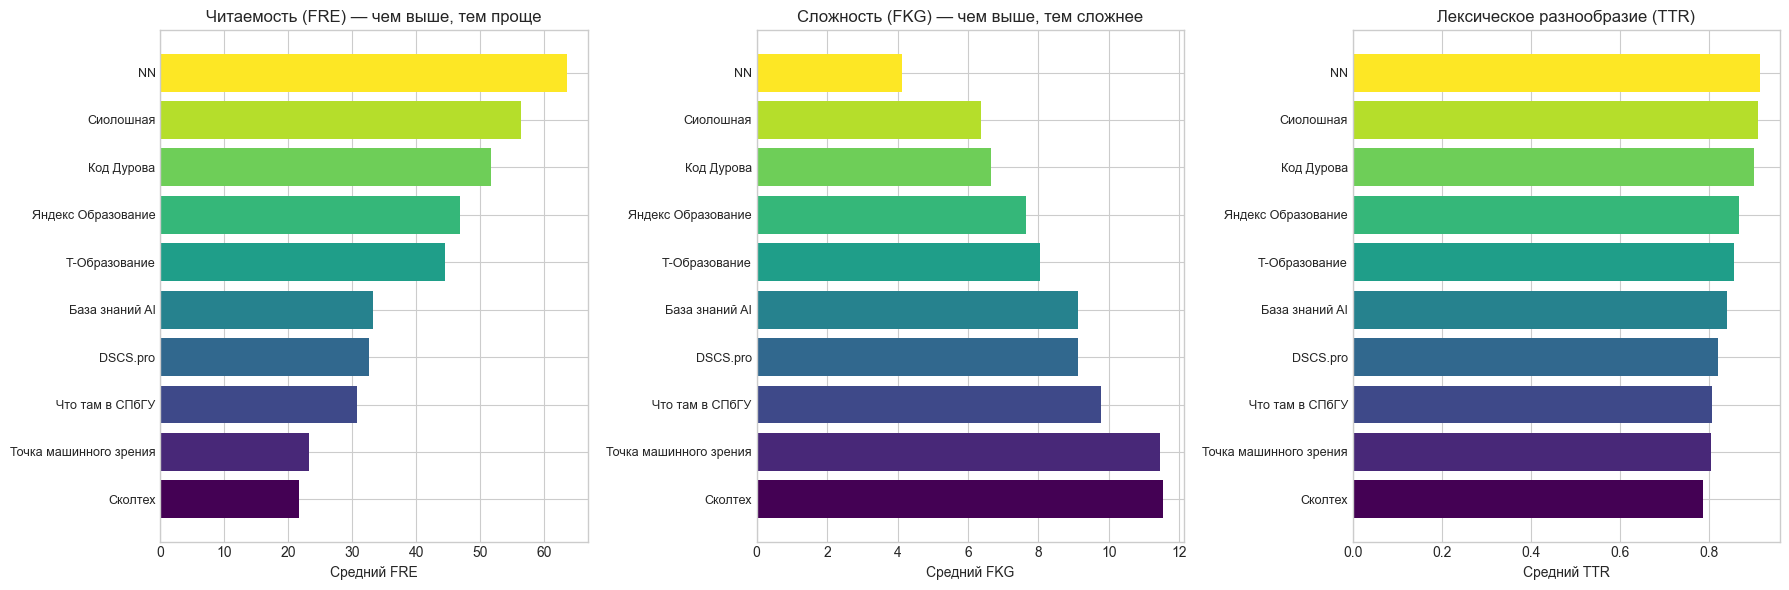

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# FRE
channels_sorted_fre = channel_stats.sort_values('flesch_reading_ease_capped', ascending=True)
labels = channels_sorted_fre.index.get_level_values('channel_title')
colors = plt.cm.viridis(np.linspace(0, 1, len(channels_sorted_fre)))
axes[0].barh(range(len(channels_sorted_fre)), channels_sorted_fre['flesch_reading_ease_capped'], color=colors)
axes[0].set_yticks(range(len(channels_sorted_fre)), labels, fontsize=9)
axes[0].set_xlabel('Средний FRE')
axes[0].set_title('Читаемость (FRE) — чем выше, тем проще')

# FKG
channels_sorted_fkg = channel_stats.sort_values('flesch_kincaid_grade_capped', ascending=False)
axes[1].barh(range(len(channels_sorted_fkg)), channels_sorted_fkg['flesch_kincaid_grade_capped'], color=colors)
axes[1].set_yticks(range(len(channels_sorted_fkg)), labels, fontsize=9)
axes[1].set_xlabel('Средний FKG')
axes[1].set_title('Сложность (FKG) — чем выше, тем сложнее')

# TTR
channels_sorted_ttr = channel_stats.sort_values('ttr', ascending=True)
axes[2].barh(range(len(channels_sorted_ttr)), channels_sorted_ttr['ttr'], color=colors)
axes[2].set_yticks(range(len(channels_sorted_ttr)), labels, fontsize=9)
axes[2].set_xlabel('Средний TTR')
axes[2].set_title('Лексическое разнообразие (TTR)')

plt.tight_layout()
plt.savefig('../data/plots/channels_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Box-plot

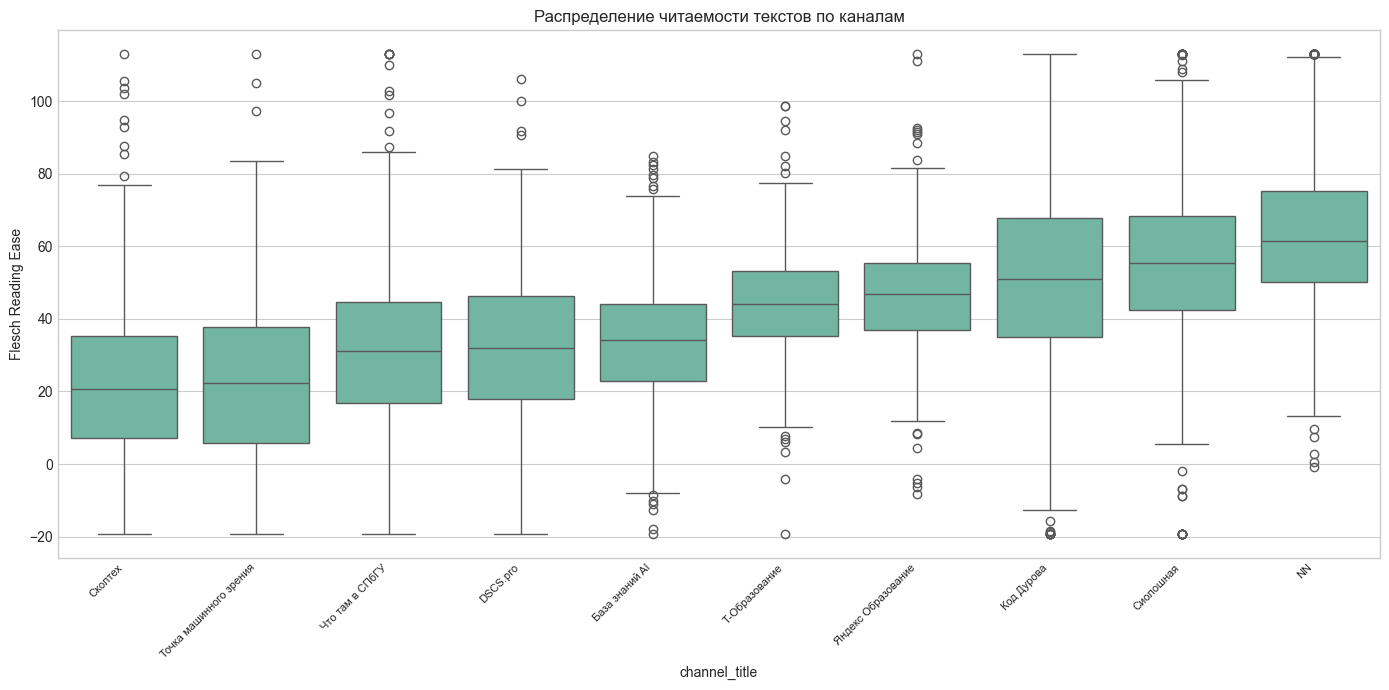

In [66]:
plt.figure(figsize=(14, 7))
order = df_clean.groupby('channel_title')['flesch_reading_ease_capped'].median().sort_values().index
sns.boxplot(data=df_clean, x='channel_title', y='flesch_reading_ease_capped', order=order)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Flesch Reading Ease')
plt.title('Распределение читаемости текстов по каналам')
plt.tight_layout()
plt.savefig('../data/plots/channel_fre_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Анализ оптимальных диапазонов для каждой метрики

In [74]:
def analyze_bins(data, metric, bins, labels):
    """Анализирует вовлеченность по бинам заданной метрики"""
    
    data = data.copy()
    data.loc[:, f'{metric}_bin'] = pd.cut(data[metric], bins=bins, labels=labels)
    
    bin_stats = data.groupby(f'{metric}_bin').agg({
        'engagement_rate': 'mean',
        'views_norm': 'mean',
        'reaction_norm': 'mean',
        'post_id': 'count'
    }).round(4)

    bin_stats.columns = ['avg_engagement', 'avg_views', 'avg_reactions', 'n_posts']
    return bin_stats

FRE

In [ ]:
fre_bins = [-20, 0, 20, 40, 60, 80, 100, 120]
fre_labels = ['<-20', '0-20', '20-40', '40-60', '60-80', '80-100', '100+']
fre_stats = analyze_bins(df_clean, 'flesch_reading_ease_capped', fre_bins, fre_labels)

fre_stats

C:\Users\enoni\AppData\Local\Temp\ipykernel_42092\104392554.py:5: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.loc[:, f'{metric}_bin'] = pd.cut(data[metric], bins=bins, labels=labels)


,avg_engagement,avg_views,avg_reactions,n_posts
flesch_reading_ease_capped_bin,,,,
<-20,0.0222,0.2600,0.0151,405
0-20,0.0249,0.2412,0.0172,1123
20-40,0.0215,0.2302,0.0140,2455
40-60,0.0177,0.1881,0.0103,3344
60-80,0.0147,0.1623,0.0080,2034
80-100,0.0125,0.1421,0.0068,771
100+,0.0136,0.1538,0.0074,278


FKG

In [82]:
fkg_bins = [-5, 0, 4, 8, 12, 16, 20]
fkg_labels = ['<-5', '0-4', '4-8', '8-12', '12-16', '16-20']
fkg_stats = analyze_bins(df_clean, 'flesch_kincaid_grade_capped', fkg_bins, fkg_labels)

fkg_stats

,avg_engagement,avg_views,avg_reactions,n_posts
flesch_kincaid_grade_capped_bin,,,,
<-5,0.0120,0.1406,0.0067,368
0-4,0.0139,0.1472,0.0074,1958
4-8,0.0173,0.1821,0.0100,4043
8-12,0.0213,0.2310,0.0139,2706
12-16,0.0240,0.2536,0.0164,974
16-20,0.0278,0.2900,0.0198,361


TTR

In [84]:
ttr_bins = [0, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
ttr_labels = ['<0.7', '0.7-0.8', '0.8-0.85', '0.85-0.9', '0.9-0.95', '0.95+']
ttr_stats = analyze_bins(df_clean, 'ttr', ttr_bins, ttr_labels)

ttr_stats

,avg_engagement,avg_views,avg_reactions,n_posts
ttr_bin,,,,
<0.7,0.0260,0.2830,0.0145,275
0.7-0.8,0.0283,0.2704,0.0191,1730
0.8-0.85,0.0205,0.2290,0.0128,1610
0.85-0.9,0.0170,0.1981,0.0098,2083
0.9-0.95,0.0154,0.1566,0.0087,2318
0.95+,0.0135,0.1515,0.0082,2394


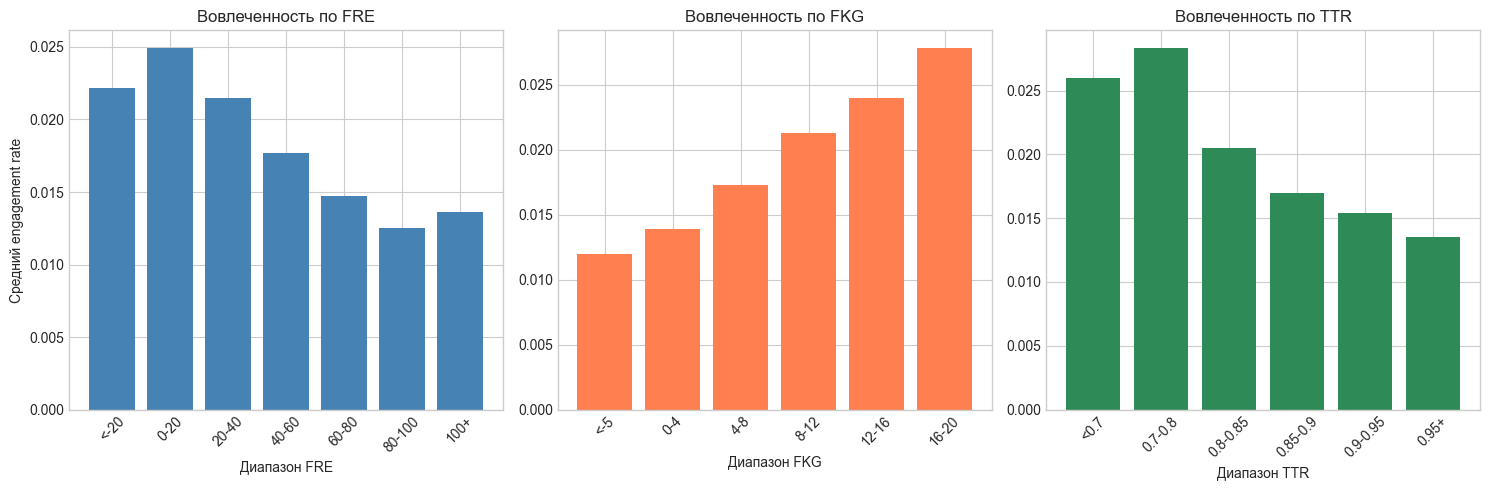

In [85]:
# Визуализация трех графиков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# FRE
axes[0].bar(range(len(fre_stats)), fre_stats['avg_engagement'], color='steelblue')
axes[0].set_xticks(range(len(fre_stats)))
axes[0].set_xticklabels(fre_stats.index, rotation=45)
axes[0].set_xlabel('Диапазон FRE')
axes[0].set_ylabel('Средний engagement rate')
axes[0].set_title('Вовлеченность по FRE')

# FKG
axes[1].bar(range(len(fkg_stats)), fkg_stats['avg_engagement'], color='coral')
axes[1].set_xticks(range(len(fkg_stats)))
axes[1].set_xticklabels(fkg_stats.index, rotation=45)
axes[1].set_xlabel('Диапазон FKG')
axes[1].set_title('Вовлеченность по FKG')

# TTR
axes[2].bar(range(len(ttr_stats)), ttr_stats['avg_engagement'], color='seagreen')
axes[2].set_xticks(range(len(ttr_stats)))
axes[2].set_xticklabels(ttr_stats.index, rotation=45)
axes[2].set_xlabel('Диапазон TTR')
axes[2].set_title('Вовлеченность по TTR')

plt.tight_layout()
plt.savefig('../data/plots/all_metrics_bins.png', dpi=300, bbox_inches='tight')
plt.show()

Максимальная вовлеченность наблюдается для текстов с FRE в диапазоне 0–20 (сложные тексты), FKG в диапазоне 16–20 (требуют высшего образования) и TTR в диапазоне 0.7–0.8 (среднее лексическое разнообразие). Это подтверждает, что аудитория профессиональных каналов готова к сложному контенту, но избегает как слишком примитивных, так и избыточно разнообразных текстов.

## Регрессионный анализ

In [93]:
import statsmodels.formula.api as smf

df_reg = df_clean.dropna(subset=['flesch_reading_ease_capped', 'flesch_kincaid_grade_capped', 
                                  'ttr', 'engagement_rate', 'channel_username'])

Влияние FRE на вовлеченность

In [94]:
model_fre = smf.ols("log_engagement_rate ~ flesch_reading_ease_capped + C(channel_username)", 
                     data=df_reg).fit(cov_type="HC3")

print(model_fre.summary().tables[1])

                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.0331      0.001     38.071      0.000       0.031       0.035
C(channel_username)[T.DSCSproAI]             0.0630      0.002     28.599      0.000       0.059       0.067
C(channel_username)[T.Education_Yandex]     -0.0175      0.001    -17.246      0.000      -0.019      -0.015
C(channel_username)[T.d_code]               -0.0204      0.001    -23.152      0.000      -0.022      -0.019
C(channel_username)[T.ict_moscow_ai]        -0.0130      0.001    -14.360      0.000      -0.015      -0.011
C(channel_username)[T.naebnet]              -0.0152      0.001    -16.640      0.000      -0.017      -0.013
C(channel_username)[T.seeallochnaya]        -0.0133      0.001    -14.061      0.000      -0.015      -0.011
C(channel_username)

Влияние FKG на вовлеченность

In [95]:
model_fkg = smf.ols("log_engagement_rate ~ flesch_kincaid_grade_capped + C(channel_username)", 
                     data=df_reg).fit(cov_type="HC3")

print(model_fkg.summary().tables[1])

                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.0299      0.001     31.251      0.000       0.028       0.032
C(channel_username)[T.DSCSproAI]             0.0630      0.002     28.671      0.000       0.059       0.067
C(channel_username)[T.Education_Yandex]     -0.0173      0.001    -16.944      0.000      -0.019      -0.015
C(channel_username)[T.d_code]               -0.0203      0.001    -22.859      0.000      -0.022      -0.019
C(channel_username)[T.ict_moscow_ai]        -0.0128      0.001    -14.157      0.000      -0.015      -0.011
C(channel_username)[T.naebnet]              -0.0150      0.001    -16.262      0.000      -0.017      -0.013
C(channel_username)[T.seeallochnaya]        -0.0137      0.001    -14.673      0.000      -0.016      -0.012
C(channel_username)

Влияние TTR на вовлеченность

In [96]:
model_ttr = smf.ols("log_engagement_rate ~ ttr + C(channel_username)", 
                     data=df_reg).fit(cov_type="HC3")

print(model_ttr.summary().tables[1])

                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.0455      0.002     25.124      0.000       0.042       0.049
C(channel_username)[T.DSCSproAI]             0.0629      0.002     28.893      0.000       0.059       0.067
C(channel_username)[T.Education_Yandex]     -0.0172      0.001    -17.313      0.000      -0.019      -0.015
C(channel_username)[T.d_code]               -0.0195      0.001    -21.932      0.000      -0.021      -0.018
C(channel_username)[T.ict_moscow_ai]        -0.0136      0.001    -15.182      0.000      -0.015      -0.012
C(channel_username)[T.naebnet]              -0.0148      0.001    -16.575      0.000      -0.017      -0.013
C(channel_username)[T.seeallochnaya]        -0.0144      0.001    -15.639      0.000      -0.016      -0.013
C(channel_username)

Все три метрики + фикс. эффекты

In [97]:
model_all = smf.ols("log_engagement_rate ~ flesch_reading_ease_capped + flesch_kincaid_grade_capped + ttr + C(channel_username)", 
                     data=df_reg).fit(cov_type="HC3")

print(model_all.summary().tables[1])

                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.0495      0.002     19.926      0.000       0.045       0.054
C(channel_username)[T.DSCSproAI]             0.0632      0.002     29.174      0.000       0.059       0.067
C(channel_username)[T.Education_Yandex]     -0.0166      0.001    -16.332      0.000      -0.019      -0.015
C(channel_username)[T.d_code]               -0.0186      0.001    -20.330      0.000      -0.020      -0.017
C(channel_username)[T.ict_moscow_ai]        -0.0134      0.001    -14.786      0.000      -0.015      -0.012
C(channel_username)[T.naebnet]              -0.0135      0.001    -14.306      0.000      -0.015      -0.012
C(channel_username)[T.seeallochnaya]        -0.0130      0.001    -13.704      0.000      -0.015      -0.011
C(channel_username)

## Взаимосвязь между метриками

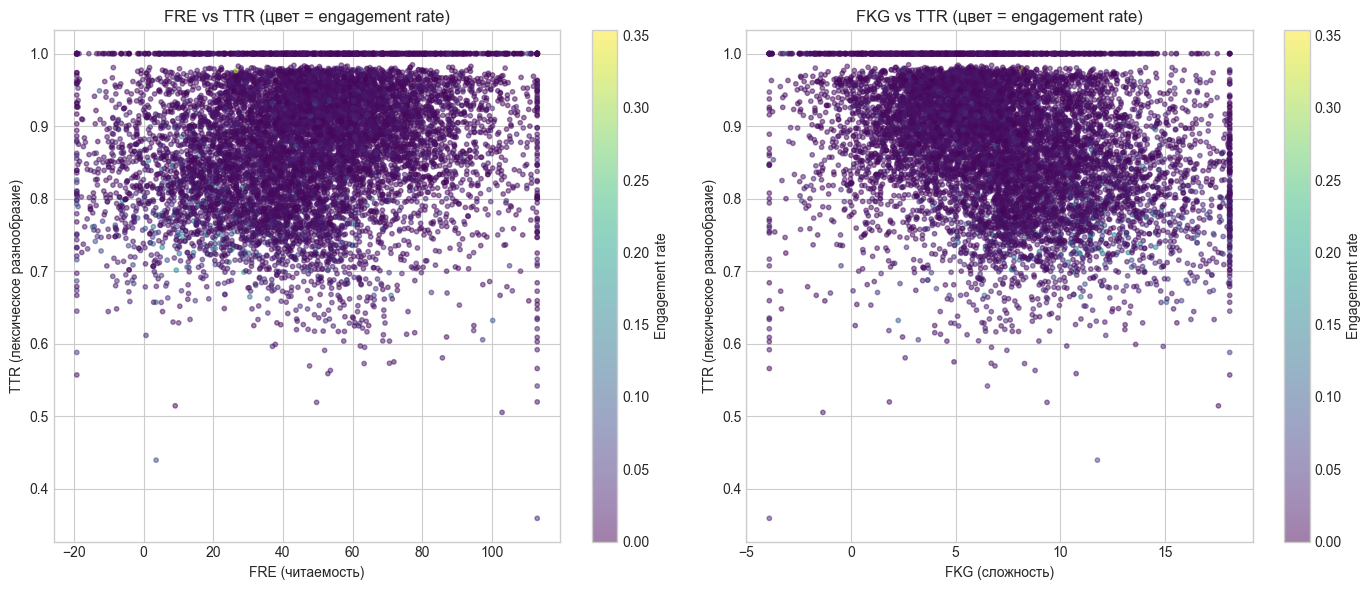

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FRE vs TTR
scatter1 = axes[0].scatter(df_clean['flesch_reading_ease_capped'], df_clean['ttr'], 
                           c=df_clean['engagement_rate'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('FRE (читаемость)')
axes[0].set_ylabel('TTR (лексическое разнообразие)')
axes[0].set_title('FRE vs TTR (цвет = engagement rate)')
plt.colorbar(scatter1, ax=axes[0], label='Engagement rate')

# FKG vs TTR
scatter2 = axes[1].scatter(df_clean['flesch_kincaid_grade_capped'], df_clean['ttr'], 
                           c=df_clean['engagement_rate'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('FKG (сложность)')
axes[1].set_ylabel('TTR (лексическое разнообразие)')
axes[1].set_title('FKG vs TTR (цвет = engagement rate)')
plt.colorbar(scatter2, ax=axes[1], label='Engagement rate')

plt.tight_layout()
plt.savefig('../data/plots/metrics_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## TTR анализ по квартилям

Статистика по квартилям TTR:
              engagement_rate  flesch_reading_ease_capped  \
ttr_quartile                                                
Q1 (низкое)            0.0265                     39.7808   
Q2                     0.0182                     45.4464   
Q3                     0.0157                     51.0246   
Q4 (высокое)           0.0136                     52.0530   

              flesch_kincaid_grade_capped  post_id  
ttr_quartile                                        
Q1 (низкое)                        9.0795     2603  
Q2                                 7.6071     2612  
Q3                                 6.3080     2596  
Q4 (высокое)                       5.7272     2599  


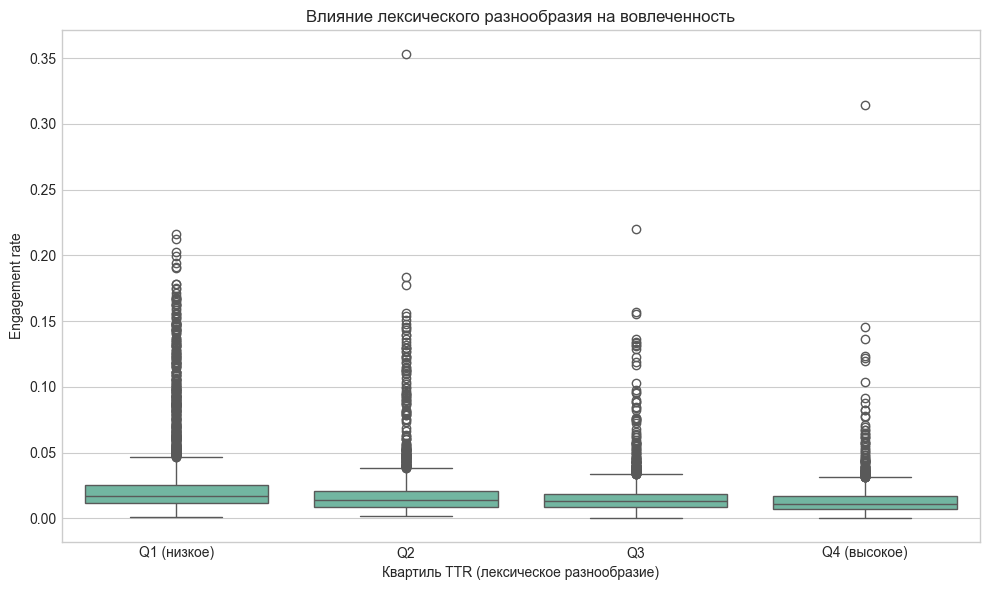

In [99]:
df_reg['ttr_quartile'] = pd.qcut(df_reg['ttr'], q=4, labels=['Q1 (низкое)', 'Q2', 'Q3', 'Q4 (высокое)'])

ttr_quartile_stats = df_reg.groupby('ttr_quartile').agg({
    'engagement_rate': 'mean',
    'flesch_reading_ease_capped': 'mean',
    'flesch_kincaid_grade_capped': 'mean',
    'post_id': 'count'
}).round(4)

print("Статистика по квартилям TTR:")
print(ttr_quartile_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_reg, x='ttr_quartile', y='engagement_rate', 
            order=['Q1 (низкое)', 'Q2', 'Q3', 'Q4 (высокое)'])
plt.xlabel('Квартиль TTR (лексическое разнообразие)')
plt.ylabel('Engagement rate')
plt.title('Влияние лексического разнообразия на вовлеченность')
plt.tight_layout()
plt.savefig('../data/plots/ttr_engagement_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Чем выше лексическое разнообразие, тем ниже вовлеченность

## Итоговая таблица

In [101]:
summary_table = df_clean.groupby(['channel_title']).agg({
    'flesch_reading_ease_capped': 'mean',
    'flesch_kincaid_grade_capped': 'mean',
    'ttr': 'mean',
    'engagement_rate': 'mean',
    'views_norm': 'mean',
    'reaction_norm': 'mean',
    'forward_norm': 'mean'
}).round(3).sort_values('engagement_rate', ascending=False)

summary_table

,flesch_reading_ease_capped,flesch_kincaid_grade_capped,ttr,engagement_rate,views_norm,reaction_norm,forward_norm
channel_title,,,,,,,
DSCS.pro,32.651,9.771,0.820,0.100,0.413,0.088,0.012
Точка машинного зрения,23.242,11.437,0.804,0.033,0.267,0.020,0.013
Сколтех,21.582,11.548,0.840,0.021,0.283,0.013,0.008
База знаний AI,33.248,9.111,0.787,0.019,0.190,0.009,0.010
Сиолошная,56.279,8.034,0.807,0.018,0.382,0.010,0.008
NN,63.575,4.136,0.911,0.016,0.096,0.007,0.009
Что там в СПбГУ,30.741,9.117,0.902,0.014,0.318,0.010,0.005
Яндекс Образование,46.863,6.651,0.867,0.014,0.325,0.007,0.007
Код Дурова,51.651,6.368,0.914,0.011,0.112,0.007,0.004


Сохраняем

In [102]:
summary_table.to_csv('../data/results/channel_summary_table.csv')

In [103]:
print("\n1. КОРРЕЛЯЦИИ С ВОВЛЕЧЕННОСТЬЮ:")
for metric in ling_features:
    corr = corr_matrix.loc[metric, 'engagement_rate']
    metric_name = {'flesch_reading_ease_capped': 'FRE', 
                   'flesch_kincaid_grade_capped': 'FKG', 
                   'ttr': 'TTR'}[metric]
    print(f"   {metric_name}: {corr:.3f}")

# Оптимальные диапазоны
print("\n2. ОПТИМАЛЬНЫЕ ДИАПАЗОНЫ:")
best_fre = fre_stats['avg_engagement'].idxmax()
best_fkg = fkg_stats['avg_engagement'].idxmax()
best_ttr = ttr_stats['avg_engagement'].idxmax()
print(f"   FRE: {best_fre} (engagement = {fre_stats.loc[best_fre, 'avg_engagement']:.4f})")
print(f"   FKG: {best_fkg} (engagement = {fkg_stats.loc[best_fkg, 'avg_engagement']:.4f})")
print(f"   TTR: {best_ttr} (engagement = {ttr_stats.loc[best_ttr, 'avg_engagement']:.4f})")

# Лучший канал по вовлеченности
best_channel = summary_table.iloc[0]
print(f"\n3. ЛУЧШИЙ КАНАЛ ПО ВОВЛЕЧЕННОСТИ:")
print(f"   {best_channel.name}: engagement_rate = {best_channel['engagement_rate']:.4f}")
print(f"   FRE = {best_channel['flesch_reading_ease_capped']:.1f}, FKG = {best_channel['flesch_kincaid_grade_capped']:.1f}, TTR = {best_channel['ttr']:.3f}")


1. КОРРЕЛЯЦИИ С ВОВЛЕЧЕННОСТЬЮ:
   FRE: -0.203
   FKG: 0.214
   TTR: -0.263

2. ОПТИМАЛЬНЫЕ ДИАПАЗОНЫ:
   FRE: 0-20 (engagement = 0.0249)
   FKG: 16-20 (engagement = 0.0278)
   TTR: 0.7-0.8 (engagement = 0.0283)

3. ЛУЧШИЙ КАНАЛ ПО ВОВЛЕЧЕННОСТИ:
   DSCS.pro: engagement_rate = 0.1000
   FRE = 32.7, FKG = 9.8, TTR = 0.820
